#### EDA (Exploratory Data Analysis)

1. Load datasets
2. Clean data (missing values,duplicates,types)
3. Treat outliers
4. Univariate and bivariate and multivariate analysis
5. insights

##### Outlier- a data point that is significantly different from other observations in a dataset.

How outliers will come---?
1. Measurement errors
2. Data entry mistakes

Why they are important---?
1. They can be errors
2. They effect the data analysis

How to identify the outliers....?
1. Statistical methods

---> Interquartile Range (IQR)

---> Z-Score

2. Visualization Techniques
---> Box Plots

---> Scatter Plots

---> Histograms


Univariate analysis--a method that analyzes a single variable to describe its characteristics and finding patterns and summarize the data.

It involves only one variable.
 
Bi variate analysis-it will give relationship between 2 variables.It helps to find if there is any co-relation ,association or connection between the 2 variables 

It involves 2 variables (x & y)

Multivariate analysis-To understand how multiple factors interact and influence with each other

It involves more than 2  

Example-

How our age,income,and education level together influence the purchasing behaviour.

### ETL

## EDA : <Dataset>

1. Load &overview

2. Cleaning (missing,dupes,dtypes)

3. Uni , Bi & multi analysis

4. Outlier -IQR

5. Feature Engineering 

6. Key Insights

Feature Engineering - " F.E is the process of turning raw data into useful features" that helps to improve the performance of machine learning models.

1. Load libraries and dataset

In [1]:
import pandas as pd
import numpy as numpy
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
# Load the coffee dataset from seaborn 
df = pd.read_csv(r"C:\Users\Sriram reddy\Downloads\Coffe_sales (4).csv")
df.head()
df.tail()

,hour_of_day,cash_type,money,coffee_name,Time_of_Day,Weekday,Month_name,Weekdaysort,Monthsort,Date,Time
3542,10,card,35.76,Cappuccino,Morning,Sun,Mar,7,3,2025-03-23,10:34:54.894000
3543,14,card,35.76,Cocoa,Afternoon,Sun,Mar,7,3,2025-03-23,14:43:37.362000
3544,14,card,35.76,Cocoa,Afternoon,Sun,Mar,7,3,2025-03-23,14:44:16.864000
3545,15,card,25.96,Americano,Afternoon,Sun,Mar,7,3,2025-03-23,15:47:28.723000
3546,18,card,35.76,Latte,Night,Sun,Mar,7,3,2025-03-23,18:11:38.635000


In [5]:
#Basic information and overview of the dataset 
print("Shape of the dataset:",df.shape)
print("\n Info about the dataset ;\n")
df.info()
#Summary Statistics 
df.describe(include='all')

Shape of the dataset: (3547, 11)

 Info about the dataset ;

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3547 entries, 0 to 3546
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   hour_of_day  3547 non-null   int64  
 1   cash_type    3547 non-null   object 
 2   money        3547 non-null   float64
 3   coffee_name  3547 non-null   object 
 4   Time_of_Day  3547 non-null   object 
 5   Weekday      3547 non-null   object 
 6   Month_name   3547 non-null   object 
 7   Weekdaysort  3547 non-null   int64  
 8   Monthsort    3547 non-null   int64  
 9   Date         3547 non-null   object 
 10  Time         3547 non-null   object 
dtypes: float64(1), int64(3), object(7)
memory usage: 304.9+ KB


,hour_of_day,cash_type,money,coffee_name,Time_of_Day,Weekday,Month_name,Weekdaysort,Monthsort,Date,Time
count,3547.000000,3547,3547.000000,3547,3547,3547,3547,3547.000000,3547.000000,3547,3547
unique,NaN,1,NaN,8,3,7,12,NaN,NaN,381,3547
top,NaN,card,NaN,Americano with Milk,Afternoon,Tue,Mar,NaN,NaN,2024-10-11,18:11:38.635000
freq,NaN,3547,NaN,809,1205,572,494,NaN,NaN,26,1
mean,14.185791,NaN,31.645216,NaN,NaN,NaN,NaN,3.845785,6.453905,NaN,NaN
std,4.234010,NaN,4.877754,NaN,NaN,NaN,NaN,1.971501,3.500754,NaN,NaN
min,6.000000,NaN,18.120000,NaN,NaN,NaN,NaN,1.000000,1.000000,NaN,NaN
25%,10.000000,NaN,27.920000,NaN,NaN,NaN,NaN,2.000000,3.000000,NaN,NaN
50%,14.000000,NaN,32.820000,NaN,NaN,NaN,NaN,4.000000,7.000000,NaN,NaN
75%,18.000000,NaN,35.760000,NaN,NaN,NaN,NaN,6.000000,10.000000,NaN,NaN


In [6]:
#Missing values analysis 

missing=pd.DataFrame({
    'missing_count':df.isnull().sum(),
    'missing_percent':(df.isnull().sum()/ len(df)) * 100
})

missing.sort_values(by='missing_percent',ascending=False)

,missing_count,missing_percent
hour_of_day,0,0.0
cash_type,0,0.0
money,0,0.0
coffee_name,0,0.0
Time_of_Day,0,0.0
Weekday,0,0.0
Month_name,0,0.0
Weekdaysort,0,0.0
Monthsort,0,0.0
Date,0,0.0


In [8]:
# 4. Handling missing values


# Fill numeric missing values with the mean
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].mean())

# Fill categorical missing values with the mode
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Drop 'deck' column only if it exists (safe check)
if 'deck' in df.columns:
    df.drop(columns=['deck'], inplace=True)

# Check remaining missing values
missing_total = df.isnull().sum().sum()
print("✅ Total missing values after cleaning:", missing_total)



✅ Total missing values after cleaning: 0


Insight:We filled important columns and removed highly missing ones.
This keeps maximum information while making the dataset clean.

In [9]:
#Duplicates and data type check

# Count duplicate rows
duplicate_count = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)

df.drop_duplicates(inplace=True)

# Verify again
print("Duplicates after removal:", df.duplicated().sum())



Number of duplicate rows: 0
Duplicates after removal: 0


Numeric Columns: ['hour_of_day', 'money', 'Weekdaysort', 'Monthsort']

Summary Statistics for Numeric Features:
       hour_of_day        money  Weekdaysort    Monthsort
count  3547.000000  3547.000000  3547.000000  3547.000000
mean     14.185791    31.645216     3.845785     6.453905
std       4.234010     4.877754     1.971501     3.500754
min       6.000000    18.120000     1.000000     1.000000
25%      10.000000    27.920000     2.000000     3.000000
50%      14.000000    32.820000     4.000000     7.000000
75%      18.000000    35.760000     6.000000    10.000000
max      22.000000    38.700000     7.000000    12.000000


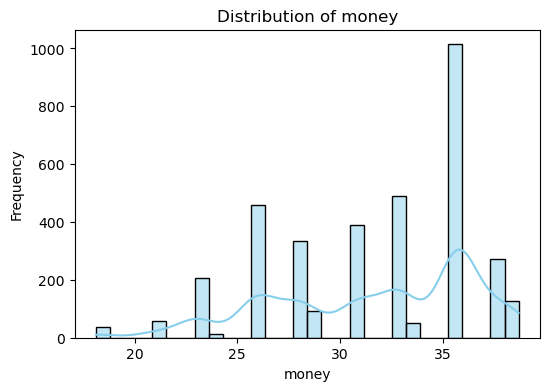

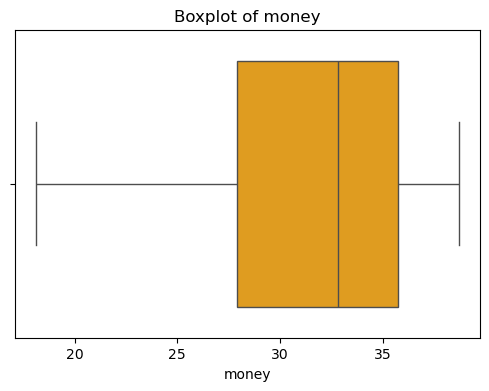

In [11]:
# 6.Univariate analysis -Numerical Features 
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
print("Numeric Columns:", num_cols.tolist())

# Summary statistics
print("\nSummary Statistics for Numeric Features:")
print(df[num_cols].describe())

# Plot histograms for each numeric feature
col=num_cols[1]
plt.figure(figsize=(6, 4))
sns.histplot(df[col], bins=30, kde=True, color='skyblue')
plt.title(f"Distribution of {col}")
plt.xlabel(col)
plt.ylabel("Frequency")
plt.show()

# Plot boxplots for each numeric feature
col=num_cols[1]
plt.figure(figsize=(6, 4))
sns.boxplot(x=df[col], color='orange')
plt.title(f"Boxplot of {col}")
plt.xlabel(col)
plt.show()

Categorical Columns: ['cash_type', 'coffee_name', 'Time_of_Day', 'Weekday', 'Month_name', 'Date', 'Time']


C:\Users\Sriram reddy\AppData\Local\Temp\ipykernel_22924\3985202358.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot(x=col, data=df, kind='count', height=4, aspect=1.5, palette='pastel')


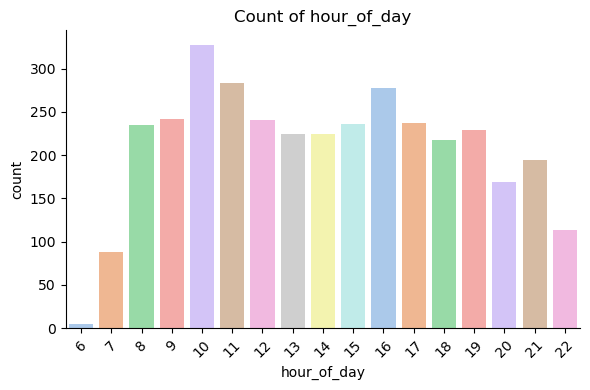

In [17]:
# Univariate Analysis - Categorical Features
# Convert all object columns to category type
df[ df.select_dtypes(include=['object']).columns ] = df.select_dtypes(include=['object']).astype('category')

# Identify categorical columns
cat_cols = df.select_dtypes(include='category').columns
print("Categorical Columns:", cat_cols.tolist())

# Plot count plots for each categorical feature
col=num_cols[0]
sns.catplot(x=col, data=df, kind='count', height=4, aspect=1.5, palette='pastel')
plt.title(f"Count of {col}")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

C:\Users\Sriram reddy\AppData\Local\Temp\ipykernel_22924\935454726.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Time_of_Day', y='money', data=df, palette='Set2')


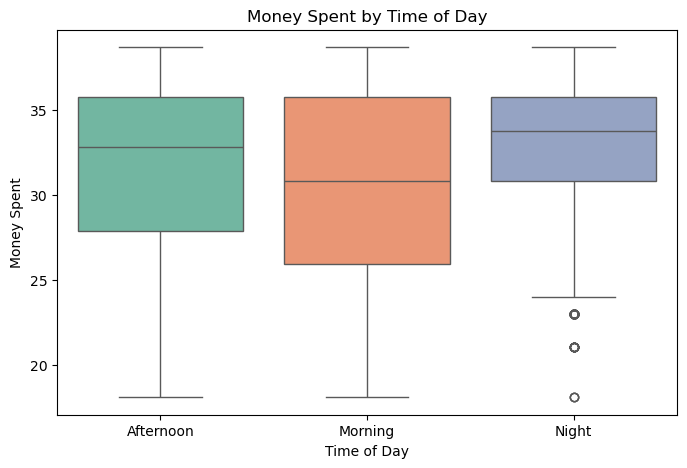

In [18]:
# Bivariate analysis - Numerical vs categorical

plt.figure(figsize=(8,5))
sns.boxplot(x='Time_of_Day', y='money', data=df, palette='Set2')
plt.title("Money Spent by Time of Day")
plt.xlabel("Time of Day")
plt.ylabel("Money Spent")
plt.show()

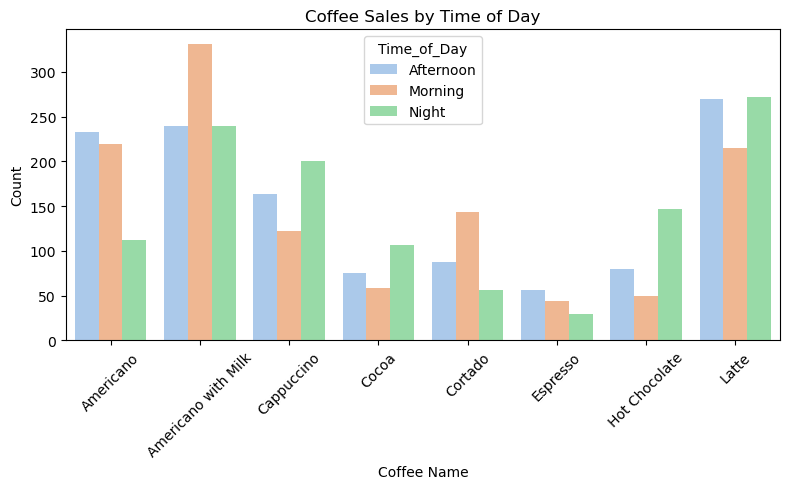

In [19]:
plt.figure(figsize=(8,5))
sns.countplot(x='coffee_name', hue='Time_of_Day', data=df, palette='pastel')
plt.title("Coffee Sales by Time of Day")
plt.xlabel("Coffee Name")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Numeric columns used for correlation: ['hour_of_day', 'money', 'Weekdaysort', 'Monthsort']


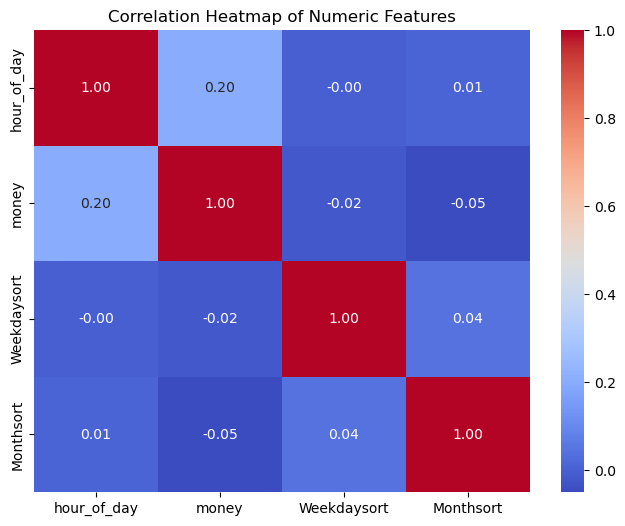

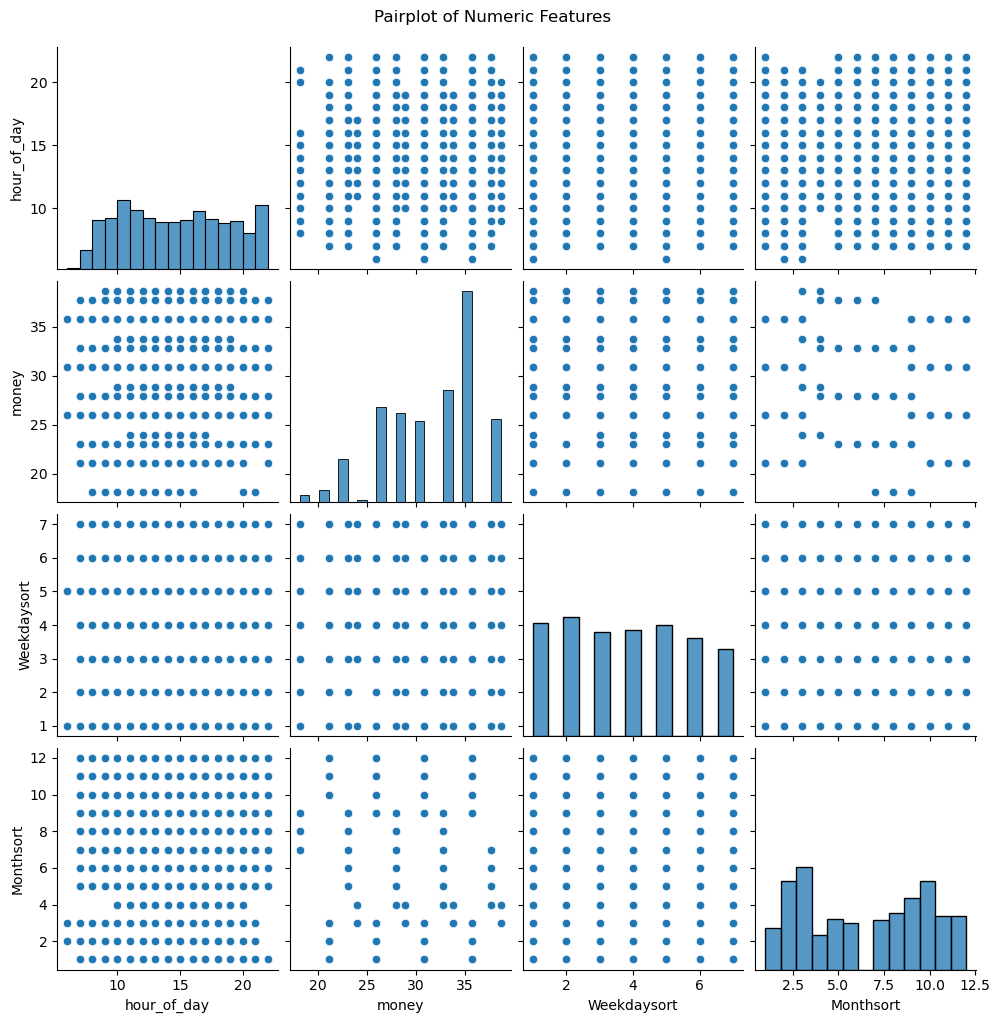

In [20]:
# Select numeric columns for correlation
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
print("Numeric columns used for correlation:", num_cols.tolist())

# Correlation heatmap
corr = df[num_cols].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap of Numeric Features")
plt.show()

# Pairplot for numeric features
sns.pairplot(df[num_cols])
plt.suptitle("Pairplot of Numeric Features", y=1.02)
plt.show()

### Insights -

1. Distribution is fairly uniform from 6 AM to 10 PM, but slight spikes around 10 AM–12 PM and 2–6 PM.

2. Suggests peak coffee sales mid-morning and mid-afternoon, which makes sense for coffee breaks.

Number of outliers in Sales: 0


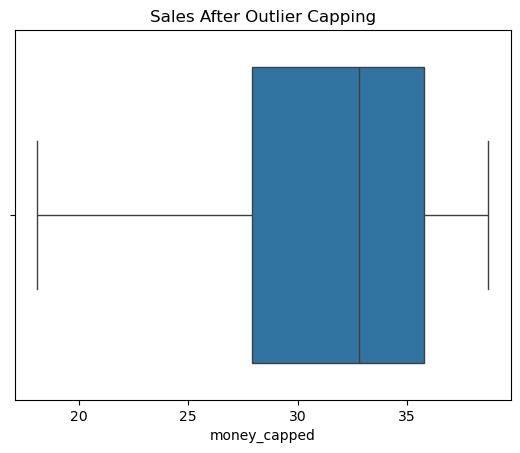

In [ ]:
# Outlier Deletion using IQR
Q1 = df['money'].quantile(0.25)
Q3 = df['money'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['money'] < lower) | (df['money'] > upper)]
print("Number of outliers in Sales:", len(outliers))

# Capping outliers
df['money_capped'] = df['money'].clip(lower, upper)
sns.boxplot(x=df['mon_capped'])
plt.title("Sales After Outlier Capping")
plt.show()


C:\Users\Sriram reddy\AppData\Local\Temp\ipykernel_22924\347682908.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  daily_sales = df.groupby('Date')['Total_Sales'].mean().reset_index()


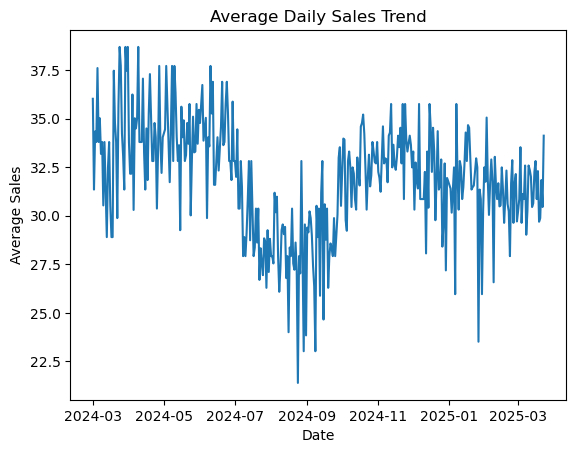

In [28]:
df['Date'] = pd.to_datetime(df['Date'])
df['Total_Sales'] = df['money']

# Average sales per day
daily_sales = df.groupby('Date')['Total_Sales'].mean().reset_index()

# Plot average sales by date
sns.lineplot(x='Date', y='Total_Sales', data=daily_sales)
plt.title("Average Daily Sales Trend")
plt.xlabel("Date")
plt.ylabel("Average Sales")
plt.show()

In [29]:
df.to_csv("coffee_sales_cleaned.csv", index=False)
print("\n✅ Cleaned Coffee Sales data saved as coffee_sales_cleaned.csv")


✅ Cleaned Coffee Sales data saved as coffee_sales_cleaned.csv


In [30]:
import os
print(os.getcwd())

c:\Users\Sriram reddy\OneDrive\Desktop\tekworks\eda assignment
